# Sec 7b - PSID state-transition matrix and eigenvalue dynamics

Rebuilds the cross-condition A-matrix figure and the eigenvalue-stability
figure from the fitted PSID model matrices. Rows of the A-matrix figure are
the DBS-both, DBS-on, DBS-off transition matrices and their difference
A_ON - A_OFF; the eigenvalue figure splits each A into its prioritised
(Xp_1) and residual (Xp_2) sub-blocks.

These are exploratory renderings. The figures the thesis includes come from
`thesis_sec7_subspace_dynamics.ipynb` cell 12; the outputs here carry a
`sec7b_explore_` prefix so the two notebooks cannot overwrite each other in
`thesis_figures/sec7/`.


In [1]:
import sys, os, re
os.chdir("/home/bobby/repos/latent-neural-dynamics-modeling")
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from modules.style import apply_thesis_style, panel_label, COLOR_DBS_OFF, COLOR_DBS_ON
from modules.loaders import (
    discover_session_run,
    EXP_Z_AS_BEHAVIOR,
    EXP_Z_AS_NEURAL,
    SESSIONS,
)
from modules.sec7_common import load_model_matrices

apply_thesis_style()
OUT = Path("thesis_figures/sec7")
OUT.mkdir(parents=True, exist_ok=True)
results_root = Path("results").resolve()
FS = 200.0


def _base_and_n1(session, exp_type):
    v, _ = discover_session_run(results_root, "psid", exp_type, session)
    base = re.sub(r"_dbs_(both|on|off)$", "", v)
    n1 = int(re.search(r"n1_(\d+)", base).group(1))
    return base, n1


## Cross-condition A matrices (z-as-behavior and z-as-neural)

In [2]:
# A-matrix cross-condition: 4 rows (both, on, off, A_ON - A_OFF) x 4 session cols.
# Exploratory variant. The thesis figure of the same name is produced by
# thesis_sec7_subspace_dynamics.ipynb, so these write under a sec7b_explore_ prefix.
LETTERS = "ABCDEFGHIJKLMNOP"


def build_a_matrix_figure(exp_type, out_name):
    row_defs = [
        ("dbs_both", "both", False),
        ("dbs_on", "on", False),
        ("dbs_off", "off", False),
        ("diff", r"$A_{\mathrm{ON}} - A_{\mathrm{OFF}}$", True),
    ]
    fig, axes = plt.subplots(4, 4, figsize=(15.5, 15.5), layout="constrained")
    im_val = im_diff = None
    for col, sess in enumerate(SESSIONS):
        base, n1 = _base_and_n1(sess, exp_type)
        A_both = load_model_matrices(base, "dbs_both")["A"]
        A_on = load_model_matrices(base, "dbs_on")["A"]
        A_off = load_model_matrices(base, "dbs_off")["A"]
        mats = {
            "dbs_both": A_both,
            "dbs_on": A_on,
            "dbs_off": A_off,
            "diff": A_on - A_off,
        }
        for row, (key, rlabel, is_diff) in enumerate(row_defs):
            ax = axes[row, col]
            A = mats[key]
            im = ax.imshow(A, cmap="RdBu_r", vmin=-1.0, vmax=1.0, interpolation="nearest")
            if is_diff:
                im_diff = im
            else:
                im_val = im
            ax.axvline(n1 - 0.5, color="k", lw=0.8)
            ax.axhline(n1 - 0.5, color="k", lw=0.8)
            ax.set_xticks([])
            ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(rlabel, fontsize=11)
            panel_label(ax, LETTERS[row * 4 + col], sess.replace("_", " "))
    fig.colorbar(im_val, ax=axes[:3, :].ravel().tolist(), shrink=0.5, label="A value")
    fig.colorbar(
        im_diff, ax=axes[3, :].ravel().tolist(), shrink=0.9,
        label=r"$A_{\mathrm{ON}} - A_{\mathrm{OFF}}$",
    )
    fig.savefig(str(OUT / out_name))
    plt.show()
    print("saved", out_name)


build_a_matrix_figure(EXP_Z_AS_BEHAVIOR, "sec7b_explore_psid_a_matrix_cross_condition_z_as_behavior.png")
build_a_matrix_figure(EXP_Z_AS_NEURAL, "sec7b_explore_psid_a_matrix_cross_condition_z_as_neural.png")


saved sec7b_explore_psid_a_matrix_cross_condition_z_as_behavior.png


saved sec7b_explore_psid_a_matrix_cross_condition_z_as_neural.png


## Eigenvalue magnitude vs oscillation frequency (z-as-behavior)

In [3]:
# Eigenvalue stability: 2 rows (Xp_1, Xp_2 subspaces) x 4 session cols.
# Xp_1 = eig(A[:n1,:n1]); Xp_2 = eig(A[n1:,n1:]). Magnitude vs oscillation freq.
_COND_MARK = [
    ("dbs_both", "DBS both", "s", COLOR_DBS_OFF),
    ("dbs_on", "DBS on", "o", COLOR_DBS_ON),
    ("dbs_off", "DBS off", "D", COLOR_DBS_OFF),
]


def _eig_mag_freq(block):
    if block.size == 0:
        return np.array([]), np.array([])
    ev = np.linalg.eigvals(block)
    mag = np.abs(ev)
    freq = np.abs(np.angle(ev)) / (2.0 * np.pi) * FS
    return freq, mag


fig, axes = plt.subplots(2, 4, figsize=(19, 9), layout="constrained")
all_min = 1.0
for col, sess in enumerate(SESSIONS):
    base, n1 = _base_and_n1(sess, EXP_Z_AS_BEHAVIOR)
    A_by_cond = {c: load_model_matrices(base, c)["A"] for c, *_ in _COND_MARK}
    for row in (0, 1):
        ax = axes[row, col]
        for cond, lbl, marker, color in _COND_MARK:
            A = A_by_cond[cond]
            block = A[:n1, :n1] if row == 0 else A[n1:, n1:]
            freq, mag = _eig_mag_freq(block)
            if mag.size:
                all_min = min(all_min, float(mag.min()))
            ax.scatter(
                freq, mag, marker=marker, s=45, facecolor=color,
                edgecolor="white", linewidth=0.4, alpha=0.9,
                label=lbl if (col == 3 and row == 1) else None,
            )
        ax.axhline(1.0, ls="--", color="k", lw=1.0)
        panel_label(ax, "ABCDEFGH"[row * 4 + col], f"{sess.replace('_', ' ')}, Xp_{row + 1}")
        if col == 0:
            ax.set_ylabel(r"$|\lambda|$ (eigenvalue magnitude)")
        if row == 1:
            ax.set_xlabel("oscillation frequency (Hz)")

ylo = min(0.965, all_min - 0.005)
for ax in axes.ravel():
    ax.set_ylim(ylo, 1.005)
axes[1, 3].legend(loc="lower right", fontsize=8, ncol=2)
fig.savefig(str(OUT / "sec7b_explore_eigenvalue_stability_all_sessions.png"))
plt.show()
print("saved sec7b_explore_eigenvalue_stability_all_sessions.png; ylo=", ylo)


saved sec7b_explore_eigenvalue_stability_all_sessions.png; ylo= 0.2828220092992129


## PSID readout loadings Cy, Cz (prioritised subspace)

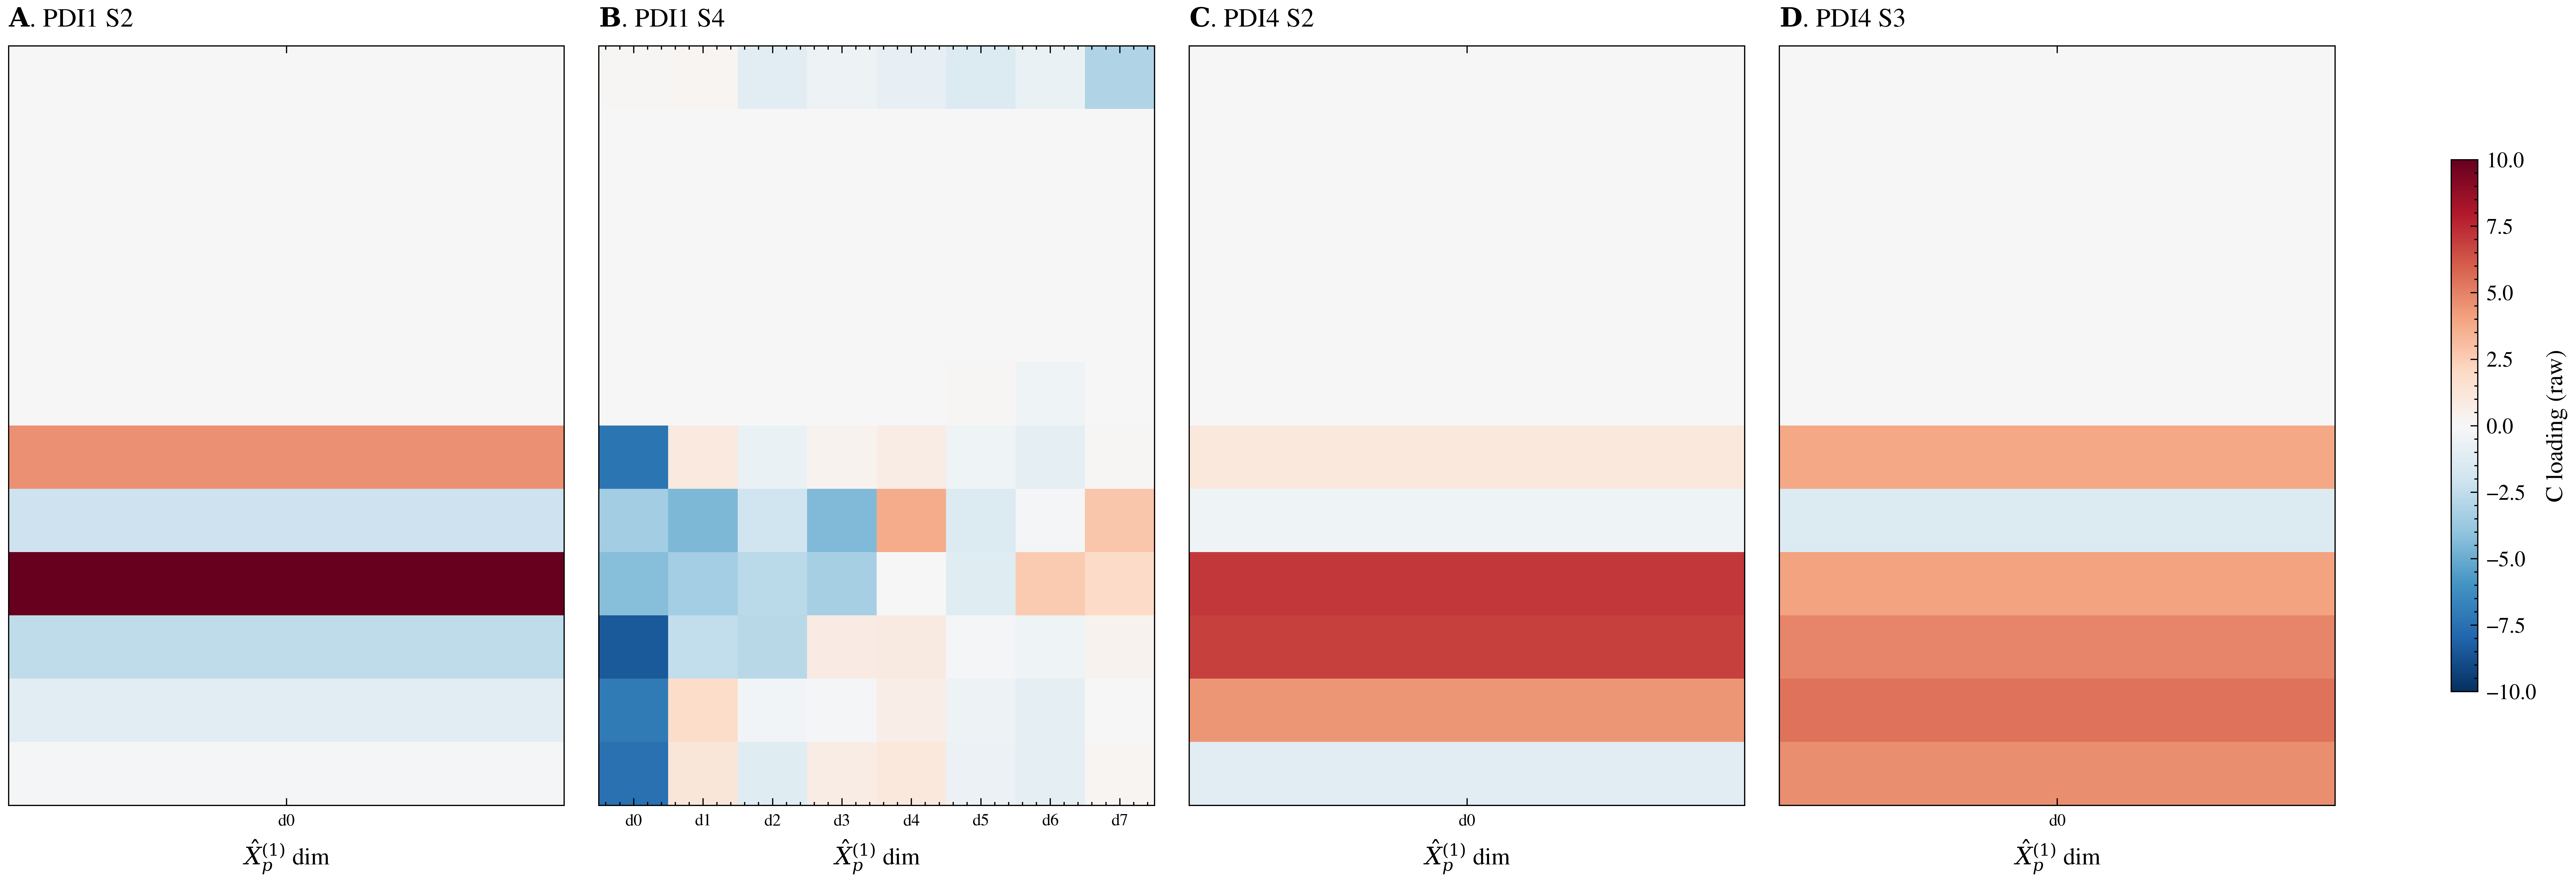

saved cy_heatmap_xp1.png


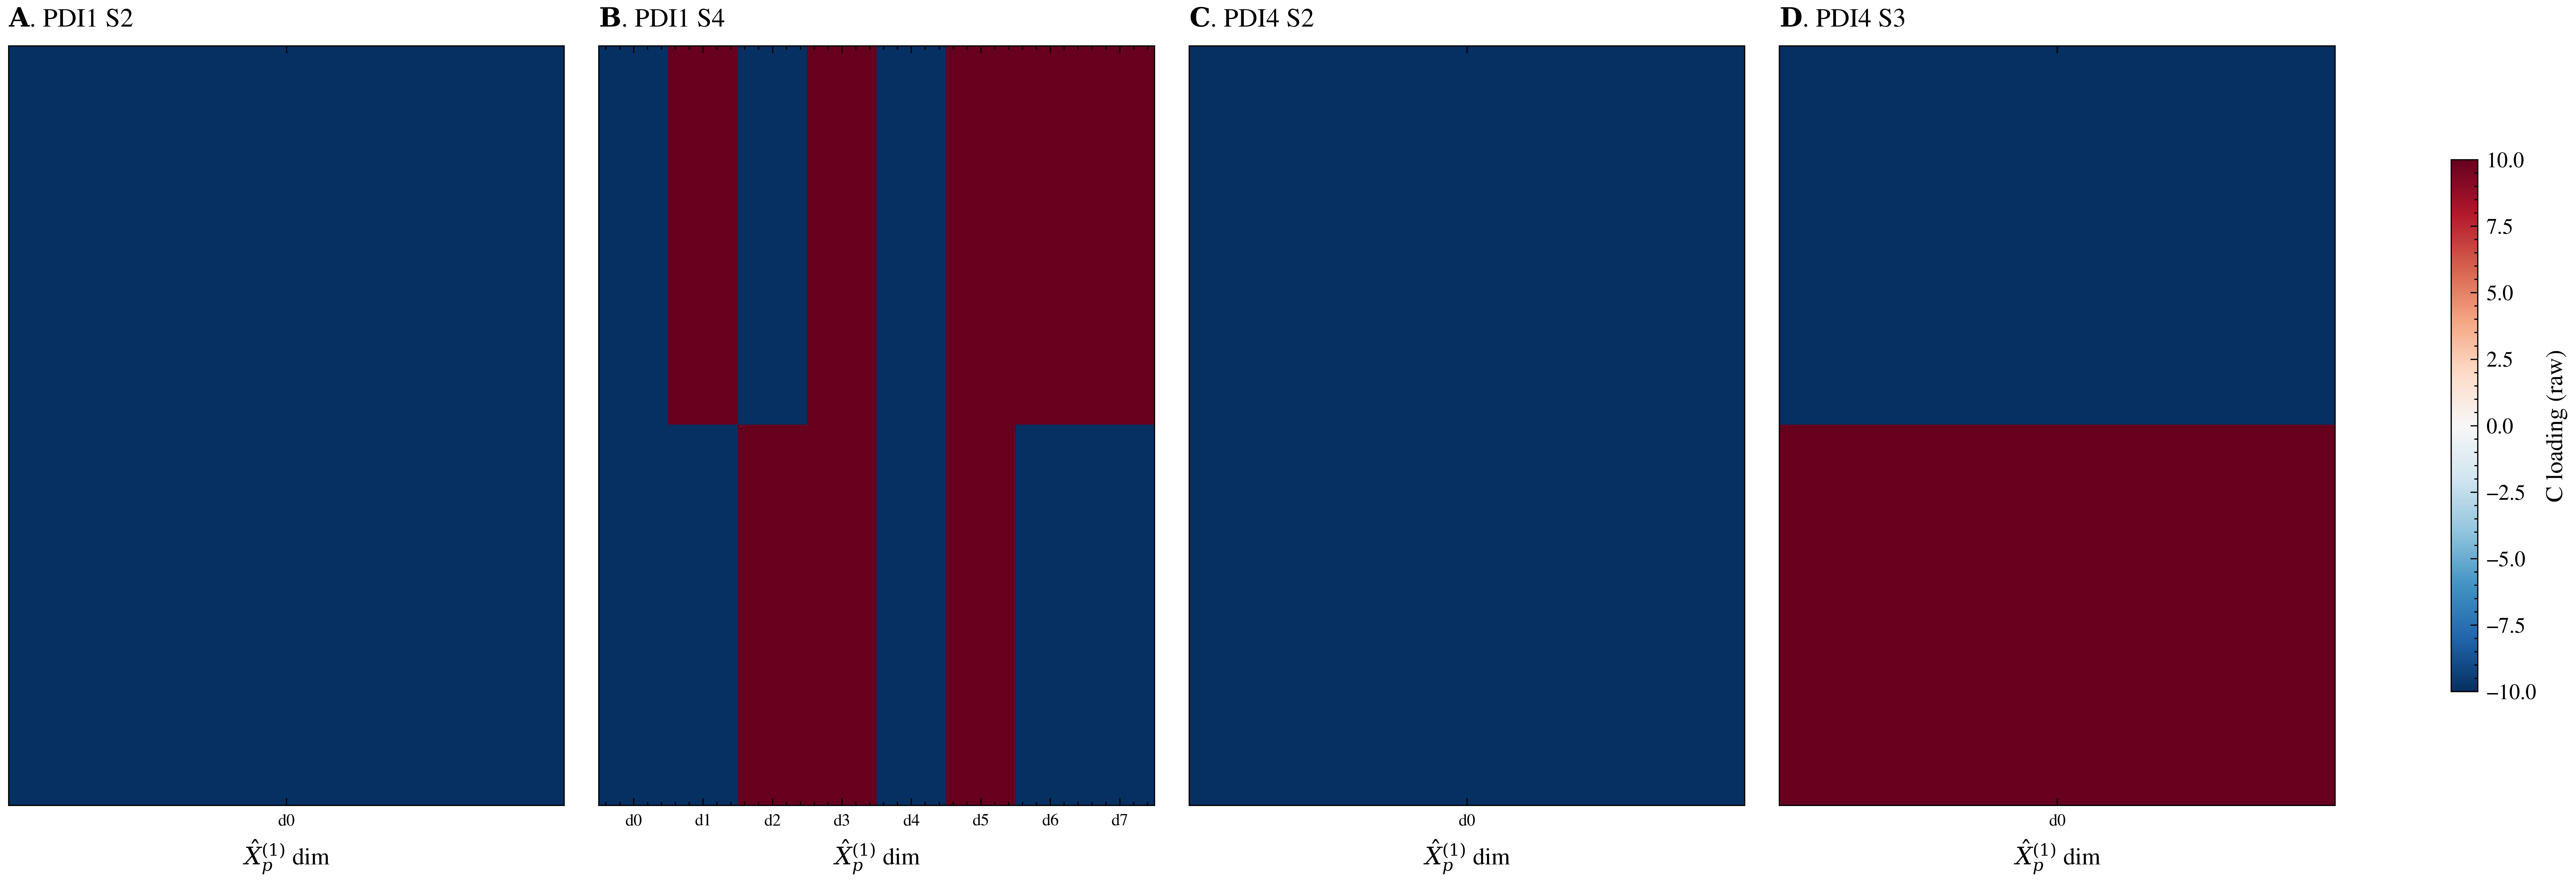

saved cz_heatmap_xp1.png


In [4]:
# PSID readout loadings (Cy, Cz) for the prioritised subspace Xp1.
from modules.loaders import load_split_results_required
from modules.lib.loaders import channels_as_str_list

def _short(name):
    return name.replace("tracing_", "").replace("_", " ")

def _readout_heatmap(which, out_name):
    fig, axes = plt.subplots(1, 4, figsize=(15, 5.2), layout="constrained")
    im = None
    for col, sess in enumerate(SESSIONS):
        base, n1 = _base_and_n1(sess, EXP_Z_AS_BEHAVIOR)
        v, ts = discover_session_run(results_root, "psid", EXP_Z_AS_BEHAVIOR, sess)
        M = load_model_matrices(base, "dbs_both")
        C = M["Cy"] if which == "y" else M["Cz"]
        sub = np.asarray(C)[:, :n1]
        res = load_split_results_required(results_root, base + "_dbs_both", ts, "test")
        feats = channels_as_str_list(res.get("input_channels" if which=="y" else "output_channels"))
        ax = axes[col]
        im = ax.imshow(sub, aspect="auto", cmap="RdBu_r", vmin=-10, vmax=10, interpolation="nearest")
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels([_short(f) for f in feats], fontsize=6 if which=="y" else 9)
        ax.set_xticks(range(n1)); ax.set_xticklabels([f"d{i}" for i in range(n1)], fontsize=7)
        ax.set_xlabel(r"$\hat{X}_p^{(1)}$ dim")
        panel_label(ax, "ABCD"[col], sess.replace("_", " "))
    fig.colorbar(im, ax=axes, shrink=0.7, label="C loading (raw)")
    fig.savefig(str(OUT / out_name)); plt.show(); print("saved", out_name)

_readout_heatmap("y", "cy_heatmap_xp1.png")
_readout_heatmap("z", "cz_heatmap_xp1.png")
